# Stack Overflow Developer Survey 2025: opis skupa podataka

## Uvod

Koliko programer zarađuje zavisi od mnogo stvari odjednom — od zemlje u kojoj radi, od toga koliko dugo
radi, od tehnologija koje koristi, od veličine firme. Neke od tih stvari se daju izmeriti, druge se ne
mere uopšte. Pitanje koje ovaj rad postavlja je koliko se razlike u platama mogu objasniti onim što se
izmeriti **može**.

Smisao takvog modela nije da nekome predvidi platu na dolar. Pre je u tome da pokaže **koja obeležja i
koliko** nose razliku: da li više znači zemlja ili iskustvo, da li se poznavanje pojedinih tehnologija
vidi na plati, i koliko od razlike ostane neobjašnjeno.

Za to koristimo **Stack Overflow Developer Survey 2025**, godišnju anketu koju Stack Overflow sprovodi
među programerima širom sveta. Rad je u Python-u, sa `pandas` za obradu i `matplotlib` i `seaborn` za
grafike.

Ovaj notebook je **prvi pogled na podatke**. Njegov posao je da opiše šta u skupu ima: odakle dolazi,
kako je složen, koliko mu vrednosti nedostaje i koje kolone su kandidati za ono što bismo predviđali.
Nijedna odluka o čišćenju, izboru ciljne promenljive ili modelu se ovde ne donosi — plan daljih koraka
je u poslednjem odeljku.

## 1. Izvor podataka i prvi pogled

Anketu Stack Overflow objavljuje javno svake godine. Skup za 2025. preuzimamo sa **Kaggle platforme**, i
to **programski** — funkcija `download_raw` iz `src/data_loader.py` preuzima fajlove preko biblioteke
`kagglehub` i kopira ih u `data/raw/`.

Zašto se kopiraju lokalno: preuzimanje se radi **jednom**, pa svako sledeće pokretanje čita isti lokalni
snimak. Kad bi se svaki put išlo na Kaggle, dataset bi se u međuvremenu mogao izmeniti i brojevi u
notebook-u prestali bi da odgovaraju tekstu. Zbog toga `data/raw/` i nije u git-u — podaci se dobijaju
pokretanjem koda.

Preuzimaju se dva fajla: `survey_results_public.csv` sa odgovorima i `survey_results_schema.csv` sa
šemom ankete. Pre nego što bilo šta kažemo o sadržaju, pogledajmo dimenzije, tipove kolona i nekoliko
stvarnih vrednosti.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import KAGGLE_DATASET, load_raw

responses, schema = load_raw()


def is_text(series):
    """True for columns pandas stores as strings, whichever string dtype it uses."""
    return series.dtype.kind in "OU" or str(series.dtype) in ("str", "string")


print(f"skup na Kaggle-u: {KAGGLE_DATASET}")
print()
print(f"odgovori:  {responses.shape[0]:>6,} redova x {responses.shape[1]:>3} kolona")
print(f"šema:      {schema.shape[0]:>6,} redova x {schema.shape[1]:>3} kolone   "
      f"{list(schema.columns)}")
print()
print(f"jedinstvenih vrednosti u ResponseId: {responses['ResponseId'].nunique():,}")
print(f"potpuno dupliranih redova:           {int(responses.duplicated().sum())}")
print()
print("tipovi kolona u odgovorima:")
for dtype, count in responses.dtypes.value_counts().items():
    print(f"  {str(dtype):<10} {count:>3}")
print()
print("prvih pet redova i prvih šest kolona, da se vidi kako vrednosti izgledaju:")
print(responses.iloc[:5, :6].to_string())

skup na Kaggle-u: edoardogalli/stack-overflow-annual-developer-survey-2025

odgovori:  49,123 redova x 170 kolona
šema:         139 redova x   6 kolone   ['qid', 'qname', 'question', 'type', 'sub', 'sq_id']

jedinstvenih vrednosti u ResponseId: 49,123


potpuno dupliranih redova:           0

tipovi kolona u odgovorima:
  str        119
  float64     50
  int64        1

prvih pet redova i prvih šest kolona, da se vidi kako vrednosti izgledaju:
   ResponseId                      MainBranch              Age                                          EdLevel                                            Employment                                   EmploymentAddl
0           1  I am a developer by profession  25-34 years old  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                              Employed  Caring for dependents (children, elderly, etc.)
1           2  I am a developer by profession  25-34 years old              Associate degree (A.A., A.S., etc.)                                              Employed                                              NaN
2           3  I am a developer by profession  35-44 years old     Bachelor’s degree (B.A., B.S., B.Eng., etc.)  Independent contractor, freelancer, or self-emp

**Zapažanje:** odgovori imaju **49.123 reda i 170 kolona**. `ResponseId` ima tačno **49.123** različite
vrednosti i nema ni jednog potpuno dupliranog reda, pa je red jedan ispitanik. Šema ima **139 redova i 6
kolona**: `qid`, `qname`, `question`, `type`, `sub`, `sq_id`.

Od 170 kolona odgovora **119 su tekstualne**, **50 brojčane** i jedna celobrojna.

U prikazanom uglu tabele svih pet ispitanika je na pitanje `MainBranch` odgovorilo
`I am a developer by profession`. Vrednosti u ostalim kolonama su duže, ali izgledaju kao ponuđeni
odgovori a ne kao slobodan tekst — `Master's degree (M.A., M.S., M.Eng., MBA, etc.)`,
`Independent contractor, freelancer, or self-employed`, `None of the above`. U drugom redu je
`EmploymentAddl` **prazan**, pa se praznine vide već u prvih pet redova.

**Tumačenje:** dimenzije su za rad ovog obima dobre — pedeset hiljada redova je dovoljno da se skup deli
na trening i test, a i da se podgrupe posmatraju odvojeno.

Ono što odmah traži objašnjenje je **broj tekstualnih kolona**. Sto devetnaest od sto sedamdeset je dve
trećine, a anketa ne izgleda kao da traži eseje — u prikazanom uglu su svi odgovori kratki i izgledaju
kao izbor iz spiska. Zašto su onda tekstualne, iz ovoga se ne vidi, i to je prvo što treba proveriti.

Broj 139 u šemi i 170 u odgovorima se ne poklapaju, pa i to treba razjasniti.

## 2. Šta je u tekstualnim kolonama

Da bismo videli šta tekstualne kolone sadrže, ne biramo ih po osećaju nego po meri: gledamo one sa
**najviše različitih vrednosti**. Ako je negde slobodan tekst, biće tamo, jer slobodan tekst skoro nikad
ne daje istu vrednost dvaput.

Uz broj različitih vrednosti ispisujemo i po jednu stvarnu vrednost iz svake, da se vidi kako izgleda.

In [2]:
text_columns = [c for c in responses.columns if is_text(responses[c])]
distinct = pd.Series({c: responses[c].nunique() for c in text_columns}).sort_values(ascending=False)

print(f"tekstualnih kolona: {len(text_columns)}")
print()
print("pet sa najviše različitih vrednosti, i po jedna stvarna vrednost iz svake:")
for name, count in distinct.head(5).items():
    example = str(responses[name].dropna().iloc[0])
    print(f"  {name:<24} {count:>6} razl.")
    print(f"      {example[:96]}")

tekstualnih kolona: 119

pet sa najviše različitih vrednosti, i po jedna stvarna vrednost iz svake:
  AIOpen                    20123 razl.
      Troubleshooting, profiling, debugging
  PlatformHaveWorkedWith    18782 razl.
      Amazon Web Services (AWS);Cloudflare;Firebase;Google Cloud;Gradle
  LanguageHaveWorkedWith    15467 razl.
      Bash/Shell (all shells);Dart;SQL
  LanguageWantToWorkWith    13724 razl.
      Dart
  PlatformWantToWorkWith    13329 razl.
      Amazon Web Services (AWS);Datadog;Docker;Homebrew;Kubernetes;Maven (build tool);Terraform


**Zapažanje:** kolona sa najviše različitih vrednosti je **`AIOpen`, sa 20.123**, i njena vrednost u
primeru je `Troubleshooting, profiling, debugging` — rečenica, bez ikakve pravilne strukture.

Odmah iza nje su **`PlatformHaveWorkedWith` (18.782)** i **`LanguageHaveWorkedWith` (15.467)**, i njihove
vrednosti izgledaju drugačije:
`Amazon Web Services (AWS);Cloudflare;Firebase;Google...` i `Bash/Shell (all shells);Dart;SQL`. To nisu
rečenice nego **spiskovi, sa tačka-zarezom između stavki**.

**Tumačenje:** dve vrste tekstualnih kolona, dakle, izgledaju sasvim različito. Jedna je slobodan tekst,
druga je više izabranih odgovora spojenih u jedan string.

Ako je to tako, onda tačka-zarez nije slučajan znak u tim vrednostima nego **razdvajač**, i mora se
javljati sistematski — u istim kolonama, kod većine odgovora. To je nešto što se može proveriti, pa
prelazimo na proveru.

### Grafik 1 — šta se dobije kad se vrednost razdvoji po tačka-zarezu

**Motivacija:** ako je tačka-zarez razdvajač, onda ono što nas zanima nisu vrednosti u koloni nego
**stavke** u njima. Zato prvo brojimo u koliko se tekstualnih kolona tačka-zarez javlja i kod kolikog
dela odgovora, a onda najširu takvu kolonu razdvojimo i nacrtamo najčešće stavke — da vidimo šta se time
dobija.

od 119 tekstualnih kolona, tačka-zarez se javlja:
  u bar 1% odgovora:  57 kolona
  u bar 50% odgovora: 47 kolona
  ni u jednom:        41 kolona



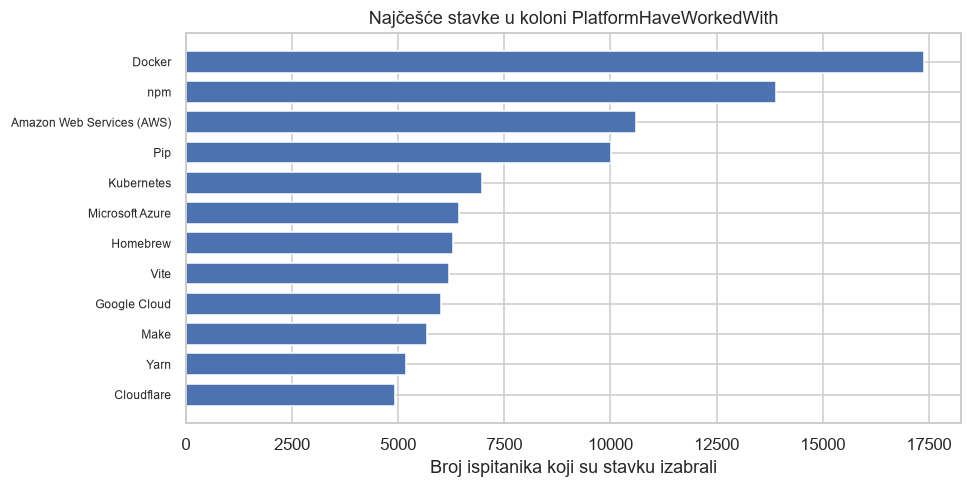

kolona PlatformHaveWorkedWith:
  odgovorilo:                          24,234 ispitanika
  različitih vrednosti u koloni:       18,782
  različitih stavki posle razdvajanja: 42
  najviše stavki u jednom odgovoru:    42
  tri najčešće stavke:
    Docker                               17,396
    npm                                  13,892
    Amazon Web Services (AWS)            10,605


In [3]:
semicolon_share = pd.Series({c: responses[c].dropna().astype(str).str.contains(";").mean()
                             for c in text_columns})

print(f"od {len(text_columns)} tekstualnih kolona, tačka-zarez se javlja:")
print(f"  u bar 1% odgovora:  {int((semicolon_share > 0.01).sum())} kolona")
print(f"  u bar 50% odgovora: {int((semicolon_share > 0.5).sum())} kolona")
print(f"  ni u jednom:        {int((semicolon_share == 0).sum())} kolona")
print()

# The widest column among those that hold lists, chosen by measurement rather
# than picked out: most distinct values among the columns with semicolons.
list_columns = list(semicolon_share[semicolon_share > 0.5].index)
widest = distinct[list_columns].idxmax()
items = responses[widest].dropna().str.split(";").explode()
counts = items.value_counts()

fig, ax = plt.subplots(figsize=(9, 4.6))
top_items = counts.head(12).iloc[::-1]
ax.barh(range(len(top_items)), top_items.to_numpy(), color="#4C72B0", height=0.72)
ax.set_yticks(range(len(top_items)))
ax.set_yticklabels([str(name)[:30] for name in top_items.index], fontsize=8)
ax.set_xlabel("Broj ispitanika koji su stavku izabrali")
ax.set_title(f"Najčešće stavke u koloni {widest}")
plt.tight_layout()
plt.show()

print(f"kolona {widest}:")
print(f"  odgovorilo:                          {responses[widest].notna().sum():,} ispitanika")
print(f"  različitih vrednosti u koloni:       {responses[widest].nunique():,}")
print(f"  različitih stavki posle razdvajanja: {counts.size}")
print(f"  najviše stavki u jednom odgovoru:    {int(items.groupby(level=0).size().max())}")
print("  tri najčešće stavke:")
for name, count in counts.head(3).items():
    print(f"    {str(name)[:34]:<36} {count:>6,}")

**Zapažanje:** provera potvrđuje da tačka-zarez nije slučajan. Od **119** tekstualnih kolona, u **57** se
javlja u bar jednom procentu odgovora, u **47** u više od polovine, a u **41** ga nema ni u jednom
odgovoru.

Razdvajanje daje čitljiv rezultat. Kolona `PlatformHaveWorkedWith` ima **18.782** različite vrednosti, ali
posle razdvajanja svega **42** različite stavke, od kojih su najčešće `Docker` (**17.396** ispitanika),
`npm` (**13.892**) i `Amazon Web Services (AWS)` (**10.605**). Odgovorilo je **24.234** ispitanika, a
jedan je izabrao svih **42** stavke.

**Tumačenje:** ovim je odgovoreno pitanje iz prethodne sekcije. Kolone nisu tekstualne zato što anketa
traži eseje, nego zato što je kod pitanja sa više dozvoljenih odgovora **ceo izbor jednog ispitanika
sačuvan kao jedan string**. Takvih kolona je 47, dakle skoro trećina svih.

Za dalji rad to znači da se takva kolona ne može uzeti kao obična kategorijska. Ako bi svaka različita
vrednost bila jedna kategorija, `PlatformHaveWorkedWith` bi dala 18.782 kategorije — a iza njih stoji
svega 42 stavke. Nešto se iz tih kolona mora izvesti, a šta i kako, nije stvar ovog notebook-a.

Slobodan tekst je drugi slučaj i ovde ga samo beležimo: `AIOpen` sa dvadeset hiljada različitih odgovora
nije nešto što se razdvaja po tačka-zarezu.

## 3. Struktura ankete

Ostaje razlika između 139 redova šeme i 170 kolona odgovora. Šema je fajl u kome za pitanja iz ankete
stoji oznaka, pun tekst i **tip**, pa ćemo strukturu pročitati odatle.

Da bi se videlo koliko kolona nosi koji tip, svaku kolonu odgovora treba vezati za pitanje iz šeme.
Vezujemo po imenu: kolona pripada onom pitanju čije je ime **najduži početak** njenog imena. Najduži, a
ne bilo koji, jer se imena pitanja preklapaju — `AIModels` je početak i imena `AIModelsHaveWorkedWith`,
pa bi kraće ime pokupilo kolone koje mu ne pripadaju.

Uz to prikazujemo i **tabelu svih pitanja**, sa po jednim redom na pitanje. Tabela je duga, pa je u
notebook-u u okviru koji se skroluje; ista tabela se izvozi i u `column_overview.csv`, gde se čita bez
skrolovanja.

In [4]:
questions = schema.drop_duplicates(subset="qname").set_index("qname")
questions.index = questions.index.astype(str)
# Longest first, so a question name never claims another question's columns.
by_length = sorted(questions.index, key=len, reverse=True)


def owning_question(column):
    """The question this column was exported from, if the schema knows one."""
    if column in questions.index:
        return column
    for name in by_length:
        if column.startswith(name):
            return name
    return None


def clean_text(value):
    """The question text with its HTML tags and line breaks taken out."""
    return "" if pd.isna(value) else re.sub(r"<[^>]+>|\s+", " ", str(value)).strip()


owner = pd.Series({column: owning_question(column) for column in responses.columns})
missing_share = responses.isna().mean().mul(100)

print(f"kolona odgovora: {len(owner)}")
print(f"  vezanih za pitanje iz šeme: {int(owner.notna().sum())}")
print(f"  bez pitanja u šemi:         {int(owner.isna().sum())}   "
      f"{list(owner[owner.isna()].index)}")
print()

linked = pd.DataFrame({"kolona": owner.index, "pitanje": owner.to_numpy()}).dropna()
linked["tip"] = linked["pitanje"].map(questions["type"])
by_type = linked.groupby("tip").agg(pitanja=("pitanje", "nunique"), kolona=("kolona", "size"))
by_type["kolona_po_pitanju"] = (by_type["kolona"] / by_type["pitanja"]).round(1)
print("koliko kolona nosi koji tip pitanja:")
print(by_type.to_string())
print(f"  ukupno {int(by_type['kolona'].sum())} kolona iz {int(by_type['pitanja'].sum())} pitanja")
print()

per_question = linked.groupby("pitanje").size()
print(f"pitanja koja daju tačno jednu kolonu: {int((per_question == 1).sum())} od {len(per_question)}")
print("pitanja izvezena kroz najviše kolona:")
for name, count in per_question.nlargest(3).items():
    print(f"  {name:<20} {count} kolona   ({questions.loc[name, 'type']})")
print()
print("po jedno pitanje svakog tipa, sa punim tekstom:")
for kind in sorted(questions["type"].dropna().unique()):
    row = questions[questions["type"] == kind].iloc[0]
    print(f"  {kind:<7} {row.name:<22} {clean_text(row['question'])[:64]}")
print()
print("da li ova dva pitanja imaju tekst u šemi:")
for name in ("CompTotal", "ConvertedCompYearly"):
    text = clean_text(questions.loc[name, "question"]) if name in questions.index else None
    print(f"  {name:<22} u šemi: {name in questions.index:<6} tekst: "
          f"{'—' if not text else text[:46]}")

kolona odgovora: 170
  vezanih za pitanje iz šeme: 168
  bez pitanja u šemi:         2   ['ResponseId', 'ConvertedCompYearly']

koliko kolona nosi koji tip pitanja:
        pitanja  kolona  kolona_po_pitanju
tip                                       
MC           48      48                1.0
Matrix       13      44                3.4
RO           47      47                1.0
TE           29      29                1.0
  ukupno 168 kolona iz 137 pitanja

pitanja koja daju tačno jednu kolonu: 124 od 137
pitanja izvezena kroz najviše kolona:
  AIAgentChallenges    5 kolona   (Matrix)
  AIAgentImpact        5 kolona   (Matrix)
  AITool               5 kolona   (Matrix)

po jedno pitanje svakog tipa, sa punim tekstom:
  MC      MainBranch             Are you someone who writes code? Please select one of the follow
  Matrix  Language               Which  programming, scripting, and markup languages  have you do
  RO      TechEndorse_1          What attracts you to a technology or causes you

In [5]:
# One row per question: what it is called, its type, how many columns it takes,
# and how much of it is missing. Long, so it goes in a box that scrolls.
overview = (linked.groupby("pitanje")
            .agg(kolona=("kolona", "size"))
            .join(questions[["type", "sub"]])
            .rename(columns={"type": "tip", "sub": "stavka"}))
overview["praznine_%"] = [round(missing_share[linked.loc[linked["pitanje"] == name, "kolona"]].mean(), 1)
                          for name in overview.index]
overview["pitanje"] = [clean_text(questions.loc[name, "question"])[:140] for name in overview.index]
overview = overview[["tip", "kolona", "praznine_%", "stavka", "pitanje"]].sort_index()

display(HTML(
    "<div style='max-height:420px; overflow-y:auto; border:1px solid #ddd; padding:4px'>"
    + overview.to_html(border=0)
    + "</div>"))
print(f"pitanja u tabeli: {len(overview)}")

# The same thing per column rather than per question, for reading outside the notebook.
per_column = pd.DataFrame({
    "column": responses.columns,
    "dtype": [str(responses[c].dtype) for c in responses.columns],
    "unique_values": [responses[c].nunique() for c in responses.columns],
    "missing_percent": missing_share.round(1).to_numpy(),
    "question_type": [questions.loc[owner[c], "type"] if pd.notna(owner[c]) else ""
                      for c in responses.columns],
    "question": [clean_text(questions.loc[owner[c], "question"]) if pd.notna(owner[c]) else ""
                 for c in responses.columns],
})
overview_path = Path.cwd().parent / "data" / "processed" / "column_overview.csv"
per_column.to_csv(overview_path, index=False, encoding="utf-8")
print(f"pun pregled po kolonama sačuvan: {overview_path.name} "
      f"({per_column.shape[0]} redova x {per_column.shape[1]} kolone)")

,tip,kolona,praznine_%,stavka,pitanje
pitanje,,,,,
AIAcc,MC,1,32.3,NaN,How much do you trust the accuracy of the output from AI tools as part of your development workflow?
AIAgentChallenges,Matrix,5,64.3,NaN,To what extent do you agree with the following statements regarding AI agents?
AIAgentChange,MC,1,35.6,NaN,Have AI tools or AI agents changed how you complete development work in the past year?
AIAgentExtWrite,TE,1,98.3,NaN,"Was the out-of-the-box agents, copilots or assistants you used in the past year not listed above? Please write them below separated by a com"
AIAgentExternal,MC,1,83.1,NaN,"You indicated you use or develop AI agents as part of your development work. Have you used any of the following out-of-the-box agents, copil"
AIAgentImpact,Matrix,5,85.3,NaN,To what extent do you agree with the following statements regarding the impact of AI agents on your work as a developer?
AIAgentKnowWrite,TE,1,98.4,NaN,Was the tool or tools for AI agent orchestration or agent frameworks you used in the past year not listed above? Please write them below sep
AIAgentKnowledge,MC,1,93.1,NaN,You indicated you use or develop AI agents as part of your development work. Have you used any of the following tools for AI agent memory or
AIAgentObsWrite,TE,1,99.5,NaN,"Was the tool or tools for AI agent observability, monitoring or security you used in the past year not listed above? Please write them below"


pitanja u tabeli: 137
pun pregled po kolonama sačuvan: column_overview.csv (170 redova x 6 kolone)


**Zapažanje:** od 170 kolona, **168 je vezano za pitanje iz šeme**, a dve nisu: `ResponseId` i
`ConvertedCompYearly`.

Tih 168 kolona dolazi iz **137 pitanja**, po tipovima:

| tip | pitanja | kolona | kolona po pitanju |
| --- | --- | --- | --- |
| `MC` | 48 | 48 | 1,0 |
| `Matrix` | 13 | 44 | 3,4 |
| `RO` | 47 | 47 | 1,0 |
| `TE` | 29 | 29 | 1,0 |

**124 od 137 pitanja daje tačno jednu kolonu.** Šire se samo pitanja tipa `Matrix`, najviše
`AIAgentChallenges`, `AIAgentImpact` i `AITool`, sa po pet kolona.

Poslednji deo ispisa gleda dve kolone koje se po imenu tiču kompenzacije: **`CompTotal` ima tekst
pitanja u šemi, a `ConvertedCompYearly` ga nema.**

**Tumačenje:** razlika 139 naspram 170 je time razjašnjena. Pitanje tipa `Matrix` je u anketi jedna
tabela, ali u podacima postaje nekoliko kolona; kod `Language` su to tri kolone. Zato je pitanja manje
nego kolona, a razlika je gotovo cela u tih trinaest matričnih pitanja.

Tipovi usput objašnjavaju i nalaz iz druge sekcije. `MC` je „Multiple Choice", pitanje sa jednim ili više
dozvoljenih odgovora, i takvih je 48 — u tu grupu spadaju i kolone sa tačka-zarezom iz druge sekcije, ali
i pitanja sa jednim odgovorom, kao `MainBranch`. `RO` je „Rank Order", i
tih 47 pitanja su pojedinačne stavke koje se rangiraju; ime im se završava brojem, kao `TechEndorse_1`, a
kolona `stavka` u tabeli pokazuje koju stavku svako od njih rangira. `TE` je „Text Entry", gde ispitanik
upisuje vrednost.

Ostaje jedna stvar koju **ne možemo da razjasnimo iz šeme**: zašto `ConvertedCompYearly` nema tekst
pitanja. Ime sugeriše da je u vezi sa `CompTotal`, ali odsustvo teksta samo po sebi ne kaže odakle ta
kolona dolazi ni kako je dobijena. To je pitanje koje ostavljamo otvoreno i vraćamo mu se kad budemo
birali šta se predviđa.

## 4. Ko je odgovorio na anketu

Problem koji smo u uvodu postavili tiče se plata **širom sveta**, pa je prvo što o uzorku treba znati
odakle su ispitanici i čime se bave.

Uz to nas zanima i koja su pitanja **skoro svi** odgovorili, jer se odatle vidi šta je u anketi
obavezno a šta ne. Te kolone ne biramo unapred nego ih uzimamo po meri: one sa najmanje praznih
vrednosti.

### Grafik 2 — sastav uzorka

**Motivacija:** ako je uzorak pretežno iz jedne zemlje ili iz jedne vrste posla, to oblikuje sve što se
kasnije o platama može reći. Crtamo dve slike: odakle su ispitanici i kako su odgovorili na pitanje koje
je u anketi prvo i obavezno.

deset kolona sa najmanje praznih vrednosti:
  ResponseId           0.0% praznih   49123 razl.   
  MainBranch           0.0% praznih       6 razl.   Are you someone who writes code? Please sele
  Age                  0.0% praznih       7 razl.   What is your age?
  Employment           1.7% praznih       6 razl.   Which of the following best describes your c
  EdLevel              2.1% praznih       8 razl.   Which of the following best describes the hi
  LearnCodeChoose      4.7% praznih       3 razl.   Did you begin learning to code or learn a ne
  LearnCodeAI          8.1% praznih       5 razl.   Did you spend time in the last year learning
  EmploymentAddl       8.8% praznih     171 razl.   Which of the following  additional  activiti
  DevType             11.2% praznih      32 razl.   Which of the following describes your curren
  YearsCode           12.5% praznih      78 razl.   Including any education, how many years have



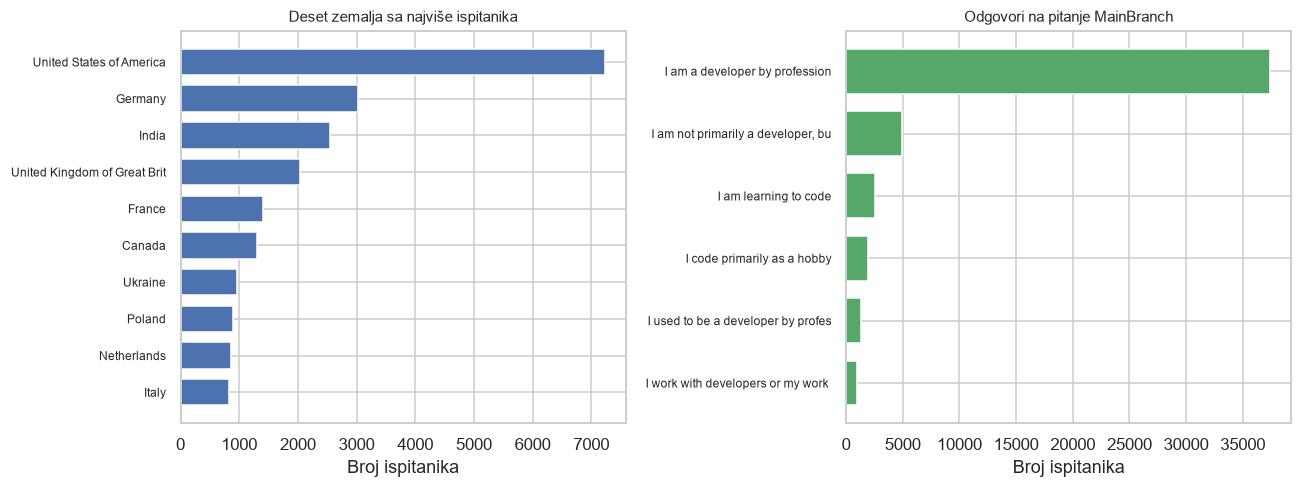

zemalja u anketi: 177   praznih u koloni Country: 27.9%
  United States of America                    7,226 (20.4%)
  Germany                                     3,022 ( 8.5%)
  India                                       2,542 ( 7.2%)
  prvih deset zemalja nosi 59.6% odgovorenih
  zemalja sa manje od 100 ispitanika: 124

MainBranch:
  I am a developer by profession                         37,418 (76.2%)
  I am not primarily a developer, but I write code som    4,888 (10.0%)
  I am learning to code                                   2,580 ( 5.3%)
  I code primarily as a hobby                             1,920 ( 3.9%)
  I used to be a developer by profession, but no longe    1,322 ( 2.7%)
  I work with developers or my work supports developer      995 ( 2.0%)


In [6]:
print("deset kolona sa najmanje praznih vrednosti:")
for name, value in missing_share.nsmallest(10).items():
    text = clean_text(questions.loc[name, "question"])[:44] if name in questions.index else ""
    print(f"  {name:<18} {value:>5.1f}% praznih   {responses[name].nunique():>5} razl.   {text}")
print()

countries = responses["Country"].value_counts()
branches = responses["MainBranch"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
top_countries = countries.head(10).iloc[::-1]
ax.barh(range(len(top_countries)), top_countries.to_numpy(), color="#4C72B0", height=0.72)
ax.set_yticks(range(len(top_countries)))
ax.set_yticklabels([name[:28] for name in top_countries.index], fontsize=8)
ax.set_xlabel("Broj ispitanika")
ax.set_title("Deset zemalja sa najviše ispitanika", fontsize=10)

ax = axes[1]
ordered = branches.iloc[::-1]
ax.barh(range(len(ordered)), ordered.to_numpy(), color="#55A868", height=0.72)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels([name[:34] for name in ordered.index], fontsize=8)
ax.set_xlabel("Broj ispitanika")
ax.set_title("Odgovori na pitanje MainBranch", fontsize=10)

plt.tight_layout()
plt.show()

print(f"zemalja u anketi: {countries.size}   praznih u koloni Country: "
      f"{missing_share['Country']:.1f}%")
for name, count in countries.head(3).items():
    print(f"  {name[:40]:<42} {count:>6,} ({100 * count / countries.sum():>4.1f}%)")
print(f"  prvih deset zemalja nosi {100 * countries.head(10).sum() / countries.sum():.1f}% odgovorenih")
print(f"  zemalja sa manje od 100 ispitanika: {int((countries < 100).sum())}")
print()
print("MainBranch:")
for name, count in branches.items():
    print(f"  {str(name)[:52]:<54} {count:>6,} ({100 * count / len(responses):>4.1f}%)")

**Zapažanje:** kolone sa najmanje praznina su **`ResponseId`, `MainBranch` i `Age` — sve tri bez ijedne
praznine** — pa `Employment` sa **1,7%** i `EdLevel` sa **2,1%**. Sve su to pitanja o samom ispitaniku, i
sva su na početku ankete.

Na pitanje `MainBranch` je **37.418 ispitanika, odnosno 76,2%**, odgovorilo da su programeri po zanimanju.
Ostatak je raspoređen na one kojima programiranje nije glavni posao (**10,0%**), one koji uče da programiraju
(**5,3%**), hobiste (**3,9%**), bivše programere (**2,7%**) i one koji rade sa programerima (**2,0%**).

Kolona `Country` je prazna kod **27,9%** ispitanika, dakle geografska slika stoji na nepunih tri četvrtine
uzorka. Među onima koji su odgovorili, zemalja je **177**, a raspodela je vrlo neravnomerna: Sjedinjene
Države nose **7.226 ispitanika, odnosno 20,4%**, Nemačka **8,5%**, Indija **7,2%**. Prvih deset zemalja
nosi **59,6%**, a **124 zemlje imaju manje od sto ispitanika**.

**Tumačenje:** tri nalaza.

**Uzorak je pretežno, ali ne isključivo, sastavljen od programera po zanimanju.** Tri četvrtine su tako
odgovorile, ali je preostala četvrtina raznorodna — u njoj su i oni koji uče, i hobisti, i bivši
programeri. Pitanje o plati kod tih kategorija ne mora da meri istu veličinu, pa je pre modelovanja
potrebno odlučiti čije plate uopšte modelujemo.

**Uzorak nije ravnomeran po zemljama.** Kad polovinu odgovorenih nosi desetak zemalja, a preko sto zemalja
ima manje od sto ispitanika, tvrdnje o platama biće mnogo bolje potkrepljene za neke zemlje nego za druge.

**Zemlja nedostaje kod svakog četvrtog ispitanika**, što je za obeležje koje je uvod postavio kao
deo pitanja neprijatno mnogo. To je i prvi konkretan primer nedostajanja koje nije zanemarljivo, pa sledeća
sekcija gleda kako su praznine raspoređene u celom skupu.

## 5. Nedostajuće vrednosti

Uputstvo predmeta traži da se u opisu skupa navede da li ima nedostajućih vrednosti. Kod ove ankete
odgovor nije samo procenat, jer je važnije **kako su praznine raspoređene** — po kolonama i po
ispitanicima.

Merimo tri stvari. Prvo, udeo praznih vrednosti po koloni, da se vidi da li je nedostajanje razliveno
svuda po malo ili skoncentrisano u nekoliko kolona. Drugo, kako se taj udeo menja **duž redosleda
kolona**, pošto kolone stoje u redosledu u kom anketa postavlja pitanja. Treće, koliko je pitanja
odgovorio pojedinačan ispitanik.

### Grafik 3 — raspodela praznina po kolonama i po ispitanicima

**Motivacija:** jedan procenat o celoj tabeli ne govori ni da li su praznine skoncentrisane u pojedinim
kolonama, ni da li dolaze od svih ispitanika podjednako. Crtamo zato dva prikaza: raspodelu udela
praznina po kolonama, i raspodelu broja odgovorenih pitanja po ispitaniku.

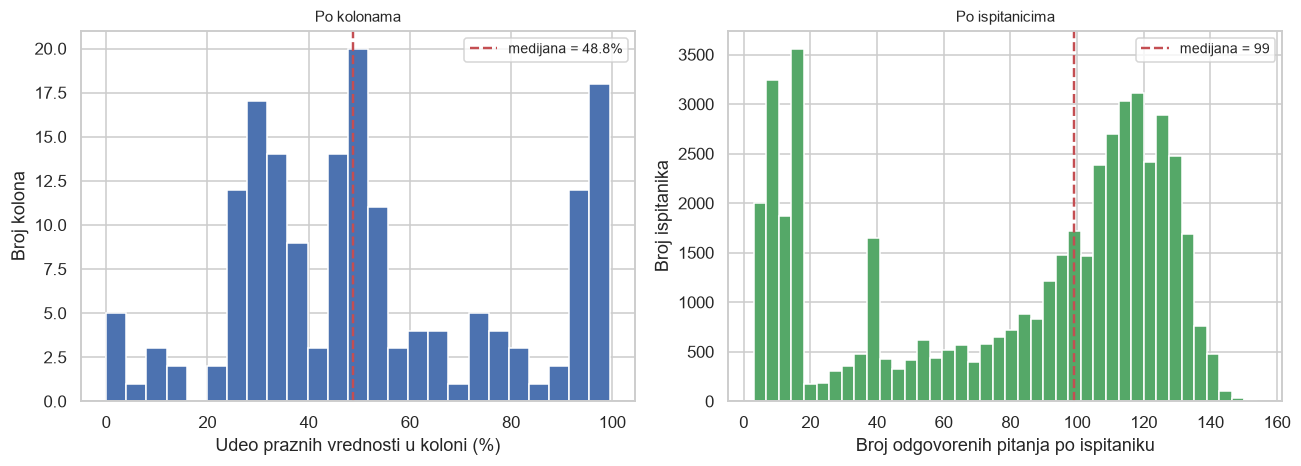

praznih ćelija u celoj tabeli: 52.5%
medijana praznina po koloni:   48.8%

koliko kolona pada u koji opseg:
  tačno 0%     3 kolona
    0 -  10%   5 kolona
   10 -  25%   5 kolona
   25 -  50%  86 kolona
   50 -  75%  29 kolona
   75 - 100%  42 kolona
  najgora kolona: AIAgentObsWrite, prazna kod 99.5%

prosek praznina po petini kolona, u redosledu kojim anketa postavlja pitanja:
  1. petina   23.3%
  2. petina   47.7%
  3. petina   65.7%
  4. petina   56.2%
  5. petina   69.3%

koliko je pitanja odgovorio pojedinačan ispitanik:
count    49123.0
mean        81.0
std         45.0
min          3.0
10%         10.0
25%         37.0
50%         99.0
75%        119.0
max        154.0
  ispitanika sa manje od 20 odgovorenih pitanja: 10,750 (21.9%)


In [7]:
answered_per_person = responses.notna().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

ax = axes[0]
ax.hist(missing_share.to_numpy(), bins=25, color="#4C72B0")
ax.axvline(missing_share.median(), color="#C44E52", linestyle="--", linewidth=1.6,
           label=f"medijana = {missing_share.median():.1f}%")
ax.set_xlabel("Udeo praznih vrednosti u koloni (%)")
ax.set_ylabel("Broj kolona")
ax.set_title("Po kolonama", fontsize=10)
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(answered_per_person.to_numpy(), bins=40, color="#55A868")
ax.axvline(answered_per_person.median(), color="#C44E52", linestyle="--", linewidth=1.6,
           label=f"medijana = {answered_per_person.median():.0f}")
ax.set_xlabel("Broj odgovorenih pitanja po ispitaniku")
ax.set_ylabel("Broj ispitanika")
ax.set_title("Po ispitanicima", fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"praznih ćelija u celoj tabeli: {100 * responses.isna().to_numpy().mean():.1f}%")
print(f"medijana praznina po koloni:   {missing_share.median():.1f}%")
print()
print("koliko kolona pada u koji opseg:")
for low, high in [(0, 0.001), (0.001, 10), (10, 25), (25, 50), (50, 75), (75, 100.1)]:
    inside = int(((missing_share >= low) & (missing_share < high)).sum())
    label = "tačno 0%" if high == 0.001 else f"{low:>3.0f} - {min(high, 100):>3.0f}%"
    print(f"  {label:<10} {inside:>3} kolona")
print(f"  najgora kolona: {missing_share.idxmax()}, prazna kod {missing_share.max():.1f}%")
print()
print("prosek praznina po petini kolona, u redosledu kojim anketa postavlja pitanja:")
for number, part in enumerate(np.array_split(missing_share.to_numpy(), 5), start=1):
    print(f"  {number}. petina  {part.mean():>5.1f}%")
print()
print("koliko je pitanja odgovorio pojedinačan ispitanik:")
print(answered_per_person.describe(percentiles=[0.1, 0.25, 0.5, 0.75]).round(0).to_string())
print(f"  ispitanika sa manje od 20 odgovorenih pitanja: "
      f"{int((answered_per_person < 20).sum()):,} ({100 * (answered_per_person < 20).mean():.1f}%)")

**Zapažanje:** praznih je **52,5% svih ćelija**, a medijana po koloni **48,8%** — dakle tipična kolona
ankete prazna je kod skoro svakog drugog ispitanika. Raspodela po kolonama je pri tome vrlo neravnomerna:

| udeo praznina u koloni | kolona |
| --- | --- |
| tačno 0% | 3 |
| do 10% | 5 |
| 10 – 25% | 5 |
| 25 – 50% | 86 |
| 50 – 75% | 29 |
| 75 – 100% | 42 |

Najgora kolona je `AIAgentObsWrite`, prazna kod **99,5%** ispitanika.

Prosek praznina **raste duž redosleda kolona**: u prvoj petini je **23,3%**, u trećoj **65,7%**, u
poslednjoj **69,3%**.

Desni grafik pokazuje raspodelu koja ima **dva grebena**. Medijana je **99** odgovorenih pitanja, ali je
prvi decil na **10** — dakle **10.750 ispitanika, odnosno 21,9%**, odgovorilo je manje od dvadeset
pitanja.

**Tumačenje:** tri merenja zajedno daju sliku koju nijedno samo ne bi.

Da je nedostajanje slučajno, ne bi raslo duž redosleda kolona ni imalo dva grebena po ispitanicima.
Ovako oba nalaza govore isto: **jedan deo ispitanika anketu nije prošao do kraja.** Skup se, dakle, sastoji
od onih koji su prošli većinu pitanja i od većeg broja onih koji su odustali blizu početka, i ta druga
grupa nosi veliki deo praznina.

To ne objašnjava sve. Kolone sa preko 75% praznina, kojih je 42, prazne su i kod ispitanika koji su anketu
prošli, pa tamo uzrok mora biti drugi — najverovatnije to što ta pitanja svi nisu ni videli, jer duge
ankete umeju da postavljaju pitanja uslovno, u zavisnosti od prethodnog odgovora. **To ovde ne
proveravamo**, jer bi tražilo da se za svaku kolonu nađe pitanje koje joj je uslov; beležimo kao pitanje
za fazu čišćenja.

Za rad iz ovoga sledi da se sa prazninama ne može postupati jednako u svim kolonama, i da odluka o njima
mora doći posle merenja, a ne pre.

## 6. Kandidati za ciljnu promenljivu

Uvod je postavio pitanje o platama, ali koja kolona to zapravo meri i da li je jedna ili ih je više, iz
uvoda se ne vidi. Zato kandidate ne biramo napamet nego po meri.

Regresija predviđa brojčanu veličinu koja ima dovoljno različitih vrednosti da se o njoj ima šta reći,
pa gledamo **brojčane kolone sa najviše različitih vrednosti**. Uz svaku nas zanima i koliko je
popunjena, jer kolona koju je odgovorila šačica ispitanika ne može biti ciljna promenljiva.

### Grafik 4 — raspodela kandidata

**Motivacija:** uputstvo traži da se u opisu skupa prikaže raspodela promenljive koja bi se predviđala.
Crtamo je onako kako se raspodela brojčane kolone i crta — histogramom, sa vrednostima na običnoj osi —
i uz grafik ispisujemo opisnu statistiku, da imamo i brojeve a ne samo sliku.

brojčane kolone sa najviše različitih vrednosti:
  ResponseId              49123 razl.   popunjeno 100.0%   —
  ConvertedCompYearly      6234 razl.   popunjeno  48.7%   —
  CompTotal                2676 razl.   popunjeno  50.6%   What is your current total  annual  comp
  ToolCountWork             114 razl.   popunjeno  56.1%   For your  primary work role  (student, d
  ToolCountPersonal          87 razl.   popunjeno  52.0%   For your  side projects or other persona
  YearsCode                  78 razl.   popunjeno  87.5%   Including any education, how many years 
  WorkExp                    72 razl.   popunjeno  87.2%   How many years of professional work expe

CompTotal:
  popunjeno 24,839 (50.6%)
  medijana  105,000
  maksimum  5.56e+74   (dakle reda 10^74)
ConvertedCompYearly:
  popunjeno 23,928 (48.7%)
  medijana  75,384
  maksimum  5e+07   (dakle reda 10^7)
kolona Currency: 142 različitih valuta



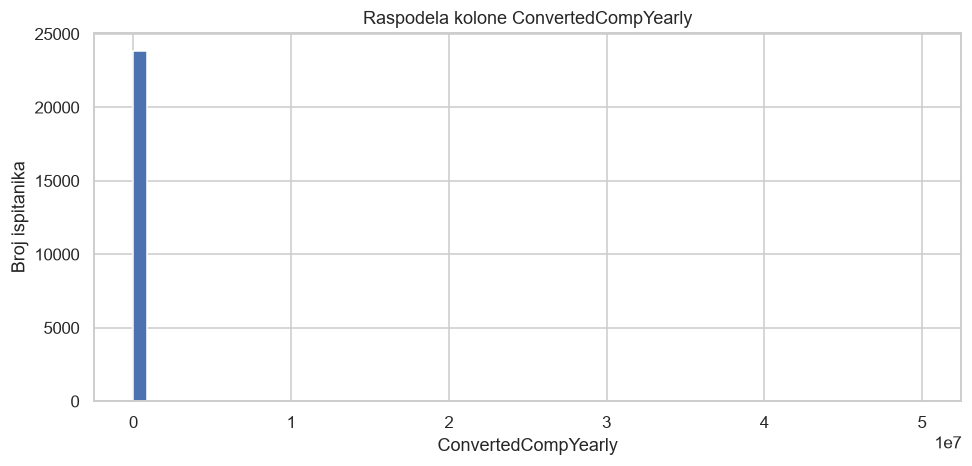

ispitanika sa prijavljenom vrednošću: 23,928
širina jednog stubića: 833,333
ispitanika u prvom stubiću:           23,858 (99.7%)
ispitanika u svim ostalim stubićima:  70

count       23928.0
mean       101792.0
std        461934.0
min             1.0
1%             65.0
25%         38171.0
50%         75384.0
75%        120630.0
99%        440856.0
max      50000000.0

odnos maksimuma i medijane:                663 puta
odnos 99. i 1. percentila:                6782 puta
odnos aritmetičke sredine i medijane:     1.35

ispitanika sa iznosom ispod 100:         304
ispitanika sa iznosom preko milion:       46


In [8]:
numeric_columns = [c for c in responses.columns if not is_text(responses[c])]
numeric_distinct = pd.Series({c: responses[c].nunique() for c in numeric_columns})
numeric_distinct = numeric_distinct.sort_values(ascending=False)

print("brojčane kolone sa najviše različitih vrednosti:")
for name, count in numeric_distinct.head(7).items():
    text = clean_text(questions.loc[name, "question"])[:40] if name in questions.index else "—"
    print(f"  {name:<22} {count:>6} razl.   popunjeno {100 - missing_share[name]:>5.1f}%   {text}")
print()

# The two columns whose names point at compensation, kept apart from the
# identifier, which has one value per respondent and predicts nothing.
CANDIDATES = ["CompTotal", "ConvertedCompYearly"]
for name in CANDIDATES:
    column = responses[name].dropna()
    print(f"{name}:")
    print(f"  popunjeno {len(column):,} ({100 * len(column) / len(responses):.1f}%)")
    print(f"  medijana  {column.median():,.0f}")
    print(f"  maksimum  {column.max():.3g}   (dakle reda 10^{int(np.log10(column.max()))})")
print(f"kolona Currency: {responses['Currency'].nunique()} različitih valuta")
print()

candidate = "ConvertedCompYearly"
values = responses[candidate].dropna()
# Sixty bars, so one bar covers a sixtieth of the range.
BINS = 60

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(values, bins=BINS, color="#4C72B0")
ax.set_xlabel(candidate)
ax.set_ylabel("Broj ispitanika")
ax.set_title(f"Raspodela kolone {candidate}")
plt.tight_layout()
plt.show()

# How much of the data lands in the leftmost bar: one bin is max/BINS wide.
first_bin = values.max() / BINS
print(f"ispitanika sa prijavljenom vrednošću: {len(values):,}")
print(f"širina jednog stubića: {first_bin:,.0f}")
print(f"ispitanika u prvom stubiću:           {int((values <= first_bin).sum()):,} "
      f"({100 * (values <= first_bin).mean():.1f}%)")
print(f"ispitanika u svim ostalim stubićima:  {int((values > first_bin).sum()):,}")
print()

# What the picture cannot show has to be said in numbers instead.
print(values.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(0).to_string())
print()
print(f"odnos maksimuma i medijane:           {values.max() / values.median():>8.0f} puta")
print(f"odnos 99. i 1. percentila:            {values.quantile(0.99) / values.quantile(0.01):>8.0f} puta")
print(f"odnos aritmetičke sredine i medijane: {values.mean() / values.median():>8.2f}")
print()
print(f"ispitanika sa iznosom ispod 100:      {int((values < 100).sum()):>6}")
print(f"ispitanika sa iznosom preko milion:   {int((values > 1e6).sum()):>6}")

**Zapažanje:** posle `ResponseId`, koji je redni broj ispitanika i ne predviđa ništa, dve brojčane kolone
sa najviše različitih vrednosti su **`ConvertedCompYearly` (6.234)** i **`CompTotal` (2.676)** — obe se po
imenu tiču kompenzacije. Slede `ToolCountWork` (114), `ToolCountPersonal` (87), `YearsCode` (78) i
`WorkExp` (72), dakle red veličine manje različitih vrednosti.

Popunjenost te dve kolone je skoro ista, **50,6%** i **48,7%**, ali su im ostale mere različite. Medijana
je **105.000** kod `CompTotal` i **75.384** kod `ConvertedCompYearly`, a maksimum **reda 10⁷⁴** kod prve
i **reda 10⁷** kod druge. Kolona `Currency` ima **142** različite valute.

**Grafik je nečitljiv.** Vidi se jedan stubić uz nulu i ništa više. Ispis to i meri: jedan stubić je
širok **833.333**, i u prvom stubiću je **23.858 od 23.928 ispitanika, dakle 99,7%** — u svim ostalim
stubićima zajedno ostaje **70** ljudi.

Pošto se sa slike ne vidi ništa, oblik opisujemo brojevima iz ispisa. Medijana je **75.384**, kvartili
**38.171** i **120.630**, a prvi i devedeset deveti percentil **65** i **440.856**. Maksimum je **663
puta** veći od medijane, devedeset deveti percentil **6.782 puta** veći od prvog, a aritmetička sredina
**1,35 puta** veća od medijane. Na krajevima su vrednosti koje ne izgledaju kao godišnja plata: **304**
ispitanika prijavila su iznos manji od sto, a **46** veći od milion.

**Tumačenje:** histogram na običnoj osi ovde ne pokazuje ništa, i to samo po sebi jeste nalaz. Da bi
99,7% vrednosti palo u jedan od šezdeset stubića, najveće vrednosti moraju biti **mnogo puta** veće od
onih oko kojih se gomila većina. Isto govore i brojevi: kad je devedeset deveti percentil skoro sedam
hiljada puta veći od prvog, vrednosti se protežu preko nekoliko redova veličine.

Isto potvrđuje i maksimum `CompTotal`-a: broj reda 10⁷⁴ nije nijedan iznos plate ni u jednoj valuti, pa
u toj koloni sigurno ima vrednosti koje su greška u unosu. Kod `ConvertedCompYearly` je maksimum reda
10⁷ — takođe sumnjivo, ali reda veličine koji je moguć.

**Kandidata, dakle, ima dva i oba se tiču kompenzacije**, ali im se medijane razlikuju za trideset
hiljada uz skoro istu popunjenost, pa nisu izražene u istoj jedinici. Kolona `Currency` sa 142 valute
nagoveštava odakle razlika, ali **kako su te dve kolone povezane i koja je od njih upotrebljiva, iz
ovoga se ne vidi.**

Ni oblik raspodele ovde ne rešavamo. Da bi se on uopšte razradio, trebalo bi prvo znati **koju** od dve
kolone koristimo, a to se iz opisa skupa ne može utvrditi. Oboje ostaje za sledeći korak.

## 7. Plan daljih koraka

Skup je opisan, a iz opisa je izašlo pet stvari koje traže odluku, i nijedna se ne može doneti bez
merenja:

1. **Dve kolone o kompenzaciji**, sa različitim medijanama i maksimumima, i 142 valute u igri. Treba
   utvrditi u kakvom su odnosu i koja je upotrebljiva kao ciljna promenljiva.
2. **Uzorak nisu samo programeri po zanimanju.** Treba odlučiti čije plate uopšte modelujemo.
3. **Praznine u polovini svih ćelija**, neravnomerno raspoređene, sa jednim delom ispitanika koji anketu
   nije prošao. Sa predavanja znamo da se čišćenje radi u četiri koraka — duplikati, strukturne greške,
   netipične vrednosti, nedostajuće vrednosti — i da se za nedostajuće vrednosti prvo utvrđuje mehanizam,
   pa tek onda bira između brisanja i imputacije.
4. **Krajnje iskošena raspodela kandidata**, sa vrednostima na obe strane koje ne izgledaju kao plate.
5. **Četrdeset sedam kolona u kojima je vrednost ceo spisak**, i još četrdeset sedam rang-pitanja. Iz njih
   se promenljive tek moraju izvesti, jer u ovom obliku ne mogu u model.

Redosled kojim to radimo prati korake sa predavanja: prvo se odredi ciljna promenljiva, pa se skup očisti
i podeli na trening i test, pa se iz preostalih kolona izvedu nove promenljive, i na kraju se grade i
porede modeli — uz metrike na test skupu i unakrsnu validaciju.

Svaki od tih koraka je u svom notebook-u, i u svakom uz odluku stoji obrazloženje, kod, rezultat i
tumačenje:

| notebook | šta obrađuje |
| --- | --- |
| `01_target_variable` | odnos dve kolone o kompenzaciji i izbor ciljne promenljive |
| `02_data_cleaning` | populacija, duplikati, strukturne greške, netipične vrednosti, nedostajuće vrednosti, podela na trening i test |
| `03_feature_engineering` | izvođenje promenljivih iz kolona sa spiskovima i rang-pitanja |
| `04_modeling` | linearna regresija i regularizovani modeli, izbor modela i merenje na test skupu |